# TP (1h) — Prototype-based Neural Networks for XAI (MVA)

Goal: implement a **prototypical classifier** on a small dataset, then build **prototype-based explanations**.

We will:
1. Train an embedding $\phi_\theta$ (simple MLP) on digits.
2. Build class prototypes (centroids) in embedding space.
3. Explain predictions by nearest prototypes and visualize "supporting" examples.
4. Add **prototype projection** onto real embedded points.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


## 1) Data

We use `sklearn.datasets.load_digits` (8×8 images).

Notation:
- inputs $x\in\mathbb{R}^{64}$
- labels $y\in\{0,\dots,9\}$

We standardize inputs for the MLP, but keep raw 8×8 images for plots.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32)     # (n, 64)
y = digits.target.astype(np.int64)     # (n,)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

print("train:", X_tr_s.shape, "test:", X_te_s.shape)


train: (1347, 64) test: (450, 64)


## 2) Embedding network $\phi_\theta$

We learn an embedding $\phi_\theta(x)\in\mathbb{R}^d$ and a linear head.

Training objective:
$$
\mathcal{L}_{cls}(\theta,W) = \frac{1}{n}\sum_i \mathrm{CE}(W\,\phi_\theta(x_i), y_i).
$$

**TODO:** choose `d_embed` and tune training epochs if needed.

In [ ]:
# TODO: set embedding dimension (try 16 / 32 / 64)
d_embed = ...

class EmbeddingNet(nn.Module):
    def __init__(self, d_embed: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, d_embed),
        )

    def forward(self, x):
        return self.net(x)

class Classifier(nn.Module):
    def __init__(self, d_embed: int, n_classes: int = 10):
        super().__init__()
        self.phi = EmbeddingNet(d_embed)
        self.head = nn.Linear(d_embed, n_classes)

    def forward(self, x):
        z = self.phi(x)
        logits = self.head(z)
        return logits, z

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Classifier(d_embed).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

bs = 128
tr_dl = DataLoader(TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr)), batch_size=bs, shuffle=True)
te_dl = DataLoader(TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_te)), batch_size=bs, shuffle=False)

def eval_head():
    model.eval()
    preds, ys = [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            xb = xb.to(device)
            logits, _ = model(xb)
            preds.append(logits.argmax(1).cpu().numpy())
            ys.append(yb.numpy())
    return accuracy_score(np.concatenate(ys), np.concatenate(preds))

for epoch in range(25):
    model.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = model(xb)
        loss = F.cross_entropy(logits, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    if (epoch+1) % 5 == 0:
        print(f"epoch {epoch+1:02d} | head test acc = {eval_head():.4f}")


/home/mafontaine/anaconda3/envs/notebook/lib/python3.12/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


epoch 05 | head test acc = 0.8600
epoch 10 | head test acc = 0.9444
epoch 15 | head test acc = 0.9667
epoch 20 | head test acc = 0.9756
epoch 25 | head test acc = 0.9756


## 3) Prototypes in embedding space

Compute embeddings $z_i=\phi_\theta(x_i)$ on train set and define prototypes:
$$
p_c = \frac{1}{|\mathcal{I}_c|}\sum_{i\in \mathcal{I}_c} z_i.
$$

Then classify:
$$
\hat y(x)=\arg\min_c \|z-p_c\|_2^2.
$$

**TODO:** implement prototypes and report accuracy.

In [ ]:
model.eval()
with torch.no_grad():
    Z_tr = model.phi(torch.from_numpy(X_tr_s).to(device)).cpu().numpy()  # (n_tr, d)

P = np.zeros((10, d_embed), dtype=np.float32)
for c in range(10):
    idx = np.where(y_tr == c)[0]
    P[c] = Z_tr[idx].mean(axis=0)

def proto_predict(X_s: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        z = model.phi(torch.from_numpy(X_s).to(device)).cpu().numpy()
    # TODO: squared distances (broadcast)
    d2 = ...
    return d2.argmin(axis=1)

pred_te = proto_predict(X_te_s)
print("prototype test acc:", accuracy_score(y_te, pred_te))


prototype test acc: 0.9555555555555556


## 4) Explanations: nearest training examples (case-based reasoning)

For a test sample $x$:
1. Compute $z=\phi_\theta(x)$.
2. Find predicted class $\hat y$ by nearest prototype.
3. Retrieve the **k nearest training samples** (in embedding) among class $\hat y$.

**TODO:** finish `explain_one` and test on a few indices.

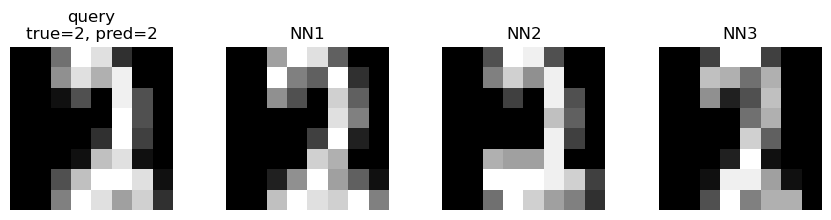

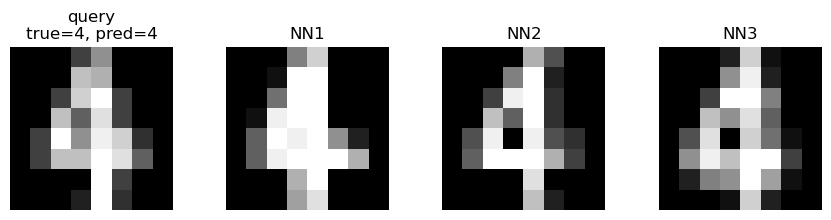

In [ ]:
# Precompute for visualization
X_tr_img = X_tr.reshape(-1, 8, 8)
X_te_img = X_te.reshape(-1, 8, 8)

def show_img(ax, img, title=""):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

def explain_one(i: int, k: int = 3):
    x = X_te_s[i:i+1]
    y_true = int(y_te[i])

    with torch.no_grad():
        z = model.phi(torch.from_numpy(x).to(device)).cpu().numpy()[0]

    # predicted class by prototypes
    d2 = ((P - z[None, :])**2).sum(axis=1)
    y_hat = int(np.argmin(d2))

    # TODO: nearest neighbors among training points of class y_hat
    idx_c = # np.where(...)
    d2_c = # Euclidean distance
    nn_idx = # "idx_c argsort"

    fig, axes = plt.subplots(1, k+1, figsize=(2.2*(k+1), 2.2))
    show_img(axes[0], X_te_img[i], title=f"query\ntrue={y_true}, pred={y_hat}")
    for j, idx in enumerate(nn_idx, start=1):
        show_img(axes[j], X_tr_img[idx], title=f"NN{j}")
    plt.tight_layout()
    plt.show()

# Try a few
explain_one(0, k=3)
explain_one(7, k=3)


## 5) Bonus: prototype projection

Replace each centroid prototype by the nearest embedded training point of that class:
$$
p_c^{proj} = z_{i^\star},\quad i^\star=\arg\min_{i:y_i=c}\|z_i-p_c\|_2^2.
$$

**TODO:** implement and compare accuracy + explanation gallery.

In [ ]:
# TODO: project prototypes onto real points
P_proj = P.copy()
for c in range(10):
    idx = #np.where(...)
    d2 =  # euclidean distance between Z_tr and P 
    i_star = #idx
    P_proj[c] = Z_tr[i_star]

def proto_predict_with(P_use: np.ndarray, X_s: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        z = model.phi(torch.from_numpy(X_s).to(device)).cpu().numpy()
    d2 = #euclidean distance between z and P_use
    return d2.argmin(axis=1)

pred_te_proj = proto_predict_with(P_proj, X_te_s)
print("projected-prototype acc:", accuracy_score(y_te, pred_te_proj))

# TODO: re-run explain_one after temporarily setting P = P_proj


projected-prototype acc: 0.9533333333333334


## 6) Short questions (write 3–5 lines each)

1. Why do prototypes give intrinsic explanations, while gradients are post-hoc?
2. When can prototype explanations be misleading? (dataset bias / embedding artifacts)
3. Does prototype projection always improve interpretability? What could be lost?

# 7) (Extension) ProtoPNet-style **patch-based** prototypes (mini version)

Goal: mimic ProtoPNet on digits by:
- using a small CNN to produce a feature map $F_\theta(x)\in\mathbb{R}^{H\times W\times d}$,
- defining prototypes $p_k\in\mathbb{R}^d$,
- computing prototype scores by a **max over patches**:
  $s_k(x)=\max_{i,j}\big(-\|z_{ij}(x)-p_k\|_2^2\big)$.

We also extract the **argmax location** $(i^{*},j^{*})$ to localize where each prototype matches (a crude heatmap).

## 7.1 CNN feature map

We work directly on 8×8 images. A tiny CNN is enough.

**TODO:** run training as-is (fast). Optionally increase `epochs_cnn` to get better accuracy.

In [8]:

# --- Build a small CNN backbone that outputs a feature map ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class SmallCNN(nn.Module):
    def __init__(self, d_feat=32):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 8x8
        self.conv2 = nn.Conv2d(16, d_feat, kernel_size=3, padding=1)  # 8x8
        self.pool = nn.MaxPool2d(2)  # 8x8 -> 4x4

    def forward(self, x_img):
        h = F.relu(self.conv1(x_img))
        h = self.pool(h)              # (B,16,4,4)
        h = F.relu(self.conv2(h))     # (B,d_feat,4,4)
        return h

class CNNHead(nn.Module):
    def __init__(self, d_feat=32, n_classes=10):
        super().__init__()
        self.backbone = SmallCNN(d_feat=d_feat)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(d_feat, n_classes)

    def forward(self, x_img):
        fmap = self.backbone(x_img)                # (B,d,4,4)
        z = self.gap(fmap).flatten(1)              # (B,d)
        logits = self.fc(z)                        # (B,C)
        return logits, fmap

# Re-use X_tr, X_te, y_tr, y_te from previous sections.
# Scale pixels to [0,1] (digits are in [0,16]).
X_tr_img_t = torch.from_numpy(X_tr.reshape(-1,1,8,8).astype("float32")/16.0)
X_te_img_t = torch.from_numpy(X_te.reshape(-1,1,8,8).astype("float32")/16.0)
y_tr_t = torch.from_numpy(y_tr)
y_te_t = torch.from_numpy(y_te)

tr_dl_img = DataLoader(TensorDataset(X_tr_img_t, y_tr_t), batch_size=128, shuffle=True)
te_dl_img = DataLoader(TensorDataset(X_te_img_t, y_te_t), batch_size=128, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
cnn = CNNHead(d_feat=32, n_classes=10).to(device)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3)

def eval_cnn():
    cnn.eval()
    preds, ys = [], []
    with torch.no_grad():
        for xb, yb in te_dl_img:
            xb = xb.to(device)
            logits, _ = cnn(xb)
            preds.append(logits.argmax(1).cpu().numpy())
            ys.append(yb.numpy())
    import numpy as np
    from sklearn.metrics import accuracy_score
    return accuracy_score(np.concatenate(ys), np.concatenate(preds))

epochs_cnn = 10  # TODO
for ep in range(epochs_cnn):
    cnn.train()
    for xb, yb in tr_dl_img:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = cnn(xb)
        loss = F.cross_entropy(logits, yb)
        opt_cnn.zero_grad()
        loss.backward()
        opt_cnn.step()
    if (ep+1) % 5 == 0:
        print(f"cnn epoch {ep+1:02d} | test acc = {eval_cnn():.4f}")


cnn epoch 05 | test acc = 0.3578
cnn epoch 10 | test acc = 0.4422


## 7.2 ProtoPNet-style scores: distance maps + max pooling

Let the feature map be $F_\theta(x)$ with patch vectors $z_{ij}(x)\in\mathbb{R}^d$.
For each prototype $p_k$, compute a distance map $D_k(i,j)=\|z_{ij}(x)-p_k\|_2^2$ and a score
$s_k(x)=-\min_{i,j} D_k(i,j)$.

We implement this without loops using broadcasting.

**TODO:** read `proto_scores_and_locs`

In [9]:

def proto_scores_and_locs(fmap, P):
    """
    fmap: (B, d, H, W)
    P:    (K, d) prototypes
    returns:
      scores: (B, K) where score = -min_{i,j} ||z_ij - p_k||^2
      locs:   (B, K, 2) argmin locations (i*, j*)
      dmaps:  (B, K, H, W) distance maps (for visualization)
    """
    B, d, H, W = fmap.shape
    K = P.shape[0]

    patches = fmap.permute(0, 2, 3, 1).reshape(B, H*W, d)     # (B,HW,d)
    diff = patches[:, :, None, :] - P[None, None, :, :]       # (B,HW,K,d)
    d2 = (diff**2).sum(dim=-1)                                # (B,HW,K)

    d2_min, argmin = d2.min(dim=1)                            # (B,K)
    scores = -d2_min

    i_star = argmin // W
    j_star = argmin % W
    locs = torch.stack([i_star, j_star], dim=-1)              # (B,K,2)

    dmaps = d2.permute(0, 2, 1).reshape(B, K, H, W)           # (B,K,H,W)
    return scores, locs, dmaps

# Smoke test
cnn.eval()
with torch.no_grad():
    _, fmap0 = cnn(X_te_img_t[:4].to(device))
P_tmp = torch.randn(15, fmap0.shape[1], device=device)
scores0, locs0, dmaps0 = proto_scores_and_locs(fmap0, P_tmp)
print("scores", scores0.shape, "locs", locs0.shape, "dmaps", dmaps0.shape)


scores torch.Size([4, 15]) locs torch.Size([4, 15, 2]) dmaps torch.Size([4, 15, 4, 4])


## 7.3 Create prototypes from real training patches (projection at init)

Initialize prototypes as *real* patches from the training set:
1. Compute feature maps on the training set.
2. Pick random patch vectors per class.

This is already a "projection": prototypes are actual data patches.

**TODO:** change `K_per_class` and observe how explanations change.

In [ ]:

import numpy as np

cnn.eval()
with torch.no_grad():
    fmap_tr = []
    for xb, yb in tr_dl_img:
        xb = xb.to(device)
        _, fm = cnn(xb)
        fmap_tr.append(fm.cpu())
fmap_tr = torch.cat(fmap_tr, dim=0)  # (n_tr, d, 4, 4)

def sample_patches_from_class(class_id, n_samples, fmap_tr_cpu, y_tr_np, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.where(y_tr_np == class_id)[0]
    choose = rng.choice(idx, size=n_samples, replace=True)
    loc = rng.integers(0, 16, size=n_samples)
    i = loc // 4
    j = loc % 4
    patches = []
    for t in range(n_samples):
        patches.append(fmap_tr_cpu[choose[t], :, i[t], j[t]].numpy())
    return np.stack(patches, axis=0)

K_per_class = 3  # TODO change
P_list, proto_class = [], []
for c in range(10):
    patches_c = sample_patches_from_class(c, K_per_class, fmap_tr, y_tr, seed=123+c)
    P_list.append(patches_c)
    proto_class.extend([c]*K_per_class)

P = torch.from_numpy(np.concatenate(P_list, axis=0)).float().to(device)  # (K,d)
proto_class = np.array(proto_class, dtype=np.int64)

print("K =", P.shape[0], "prototype dim =", P.shape[1])


K = 30 prototype dim = 32


## 7.4 Prototype-based classifier (simple aggregation)

Compute scores $s_k(x)$ for all prototypes, then aggregate per class:
$\ell_c(x)=\sum_{k:c(k)=c} s_k(x)$ and predict $\hat y=\arg\max_c \ell_c(x)$.

**TODO:** compute test accuracy for this prototype classifier.

In [11]:

from sklearn.metrics import accuracy_score

def proto_logits_from_fmap(fmap, P, proto_class, n_classes=10):
    scores, locs, dmaps = proto_scores_and_locs(fmap, P)
    B, K = scores.shape
    logits = torch.zeros(B, n_classes, device=scores.device)
    for c in range(n_classes):
        idx = np.where(proto_class == c)[0]
        if len(idx) > 0:
            logits[:, c] = scores[:, idx].sum(dim=1)
    return logits, scores, locs, dmaps

cnn.eval()
all_pred, all_y = [], []
with torch.no_grad():
    for xb, yb in te_dl_img:
        xb = xb.to(device)
        _, fmap = cnn(xb)
        logits, _, _, _ = proto_logits_from_fmap(fmap, P, proto_class, n_classes=10)
        all_pred.append(logits.argmax(1).cpu().numpy())
        all_y.append(yb.numpy())

import numpy as np
acc_proto_patch = accuracy_score(np.concatenate(all_y), np.concatenate(all_pred))
print("ProtoPNet-style (patch) test acc:", acc_proto_patch)


ProtoPNet-style (patch) test acc: 0.12222222222222222


## 7.5 Explanation: top prototypes + match locations

For one test image:
1. compute prototype scores $s_k(x)$ and locations $(i^{*}_k,j^{*}_k)$,
2. pick top prototypes contributing to the predicted class,
3. visualize the 8×8 image + a 4×4 grid overlay highlighting the match cell.

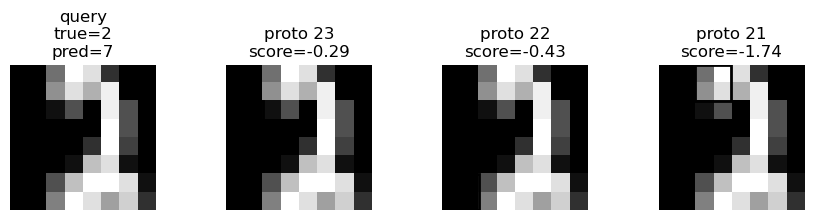

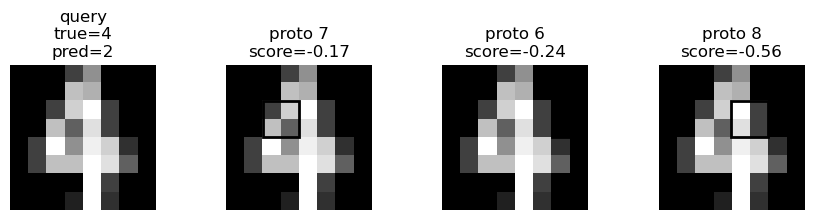

In [12]:

import matplotlib.pyplot as plt

def show_grid_overlay(ax, img8, cell, title=""):
    ax.imshow(img8, cmap="gray")
    i, j = int(cell[0]), int(cell[1])
    y0, x0 = 2*i, 2*j  # 4x4 cells -> 2x2 pixels
    rect = plt.Rectangle((x0-0.5, y0-0.5), 2, 2, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")

def explain_patch_proto(i_test: int, topk: int = 3):
    x_img = X_te_img_t[i_test:i_test+1].to(device)
    y_true = int(y_te[i_test])

    cnn.eval()
    with torch.no_grad():
        _, fmap = cnn(x_img)
        logits, scores, locs, _ = proto_logits_from_fmap(fmap, P, proto_class, n_classes=10)
        y_hat = int(logits.argmax(1).item())

    idx_c = np.where(proto_class == y_hat)[0]
    s_c = scores[0, idx_c].detach().cpu().numpy()
    order = np.argsort(-s_c)[:topk]
    top_proto = idx_c[order]

    fig, axes = plt.subplots(1, topk+1, figsize=(2.2*(topk+1), 2.2))
    axes[0].imshow(X_te[i_test].reshape(8,8), cmap="gray")
    axes[0].set_title(f"query\ntrue={y_true}\npred={y_hat}")
    axes[0].axis("off")

    for t, k in enumerate(top_proto, start=1):
        cell = locs[0, k].detach().cpu().numpy()
        show_grid_overlay(axes[t], X_te[i_test].reshape(8,8), cell,
                          title=f"proto {k}\nscore={scores[0,k].item():.2f}")
    plt.tight_layout()
    plt.show()

explain_patch_proto(0, topk=3)
explain_patch_proto(7, topk=3)


# 8. Try on your favorite dataset / system (Image, Audio, Text etc.)